# General instructions for all labs

1. To turn in:
 - this python notebook, filled out (10 pts)
 - a *standalone* PDF report that contains all the plots, and the answers to all the discussion questions (10 pts)

2. Use of ChatGPT / CoPilot / etc:
   - Allowed, but you own everything that is generated
   - This means that any part of the solution can be asked in the midterm. It can be as detailed as "What was the batch size you used in training" or specific as "what exactly does masking do in this case?" Any discussion question is also game for a quiz question.
   - If I find AI usage to be excessive. I can individually drag any of you in for a 1-1 meeting, in which I grill you on your code. If it looks like irresponsible copy/pasting, without proper understanding, I reserve the right to drastically lower your grade, or even submit cases to GGAC for ethical review.
  
3. Use of peer collaboration:
   - In general not allowed. (Discussion / comparing answers is ok, but work on actual coding independently.)
   - Exceptions can be made if you all wrote your own training script, but 1. it takes forever to train or 2. you don't have great compute resources. Then you can share a trained model amongst yourself *and declare it on your pdf*. However, the code for training *still must be written by yourself*
     


# **Lab 2: Urban Structure, Tourism, and Accessibility**

## Overview

In this lab, we will use **OpenStreetMap (OSM)** data to study how cities are structured, how people experience them as tourists, and how access to essential services varies across space. The goal is to connect **geographic data**, **simple data science tools**, and **urban reasoning**, rather than to optimize algorithms or build complex models.

OpenStreetMap is a **crowdsourced, global geographic database** that represents cities as collections of **nodes** (points), **ways** (roads or area boundaries), and **relations** (structured groups of objects). Each object is annotated with flexible **tags** (e.g., `tourism`, `amenity`, `shop`) that describe its function. Because OSM has no fixed schema, the data is rich but sparse, and requires thoughtful querying and filtering.

In this lab, we will query OSM using Python tools to:

* download street networks for entire cities,
* extract points of interest based on tag filters (e.g., `tourism=*`, `amenity=hospital`),
* treat the resulting data as a structured but imperfect dataset suitable for analysis.


## Part 0: Mapping and Visualizing a city


Pick a **large city** that is *not* Manhattan.  For example, you can pick your hometown, or where you grew up, or the closest city to where you grew up, etc.

For this city, download the street network from OpenStreetMap and visualize the resulting road graph. This will provide a first impression of the city’s scale, density, and street structure.


In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import pickle
import numpy as np

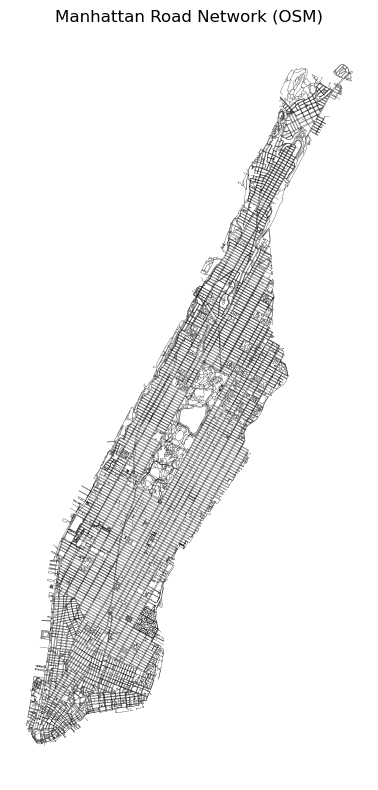

In [2]:
name = 'manhattan'
place = "Manhattan, New York City, New York, USA"
label = 'Manhattan'


# Download walking network
G = ox.graph_from_place(place, network_type="walk")

# Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)



# Plot edges (roads)
fig, ax = plt.subplots(figsize=(8, 8))

edges.plot(
    ax=ax,
    linewidth=0.1,
    color="black"
)

ax.set_title(f"{label} Road Network (OSM)")
ax.set_axis_off()
plt.tight_layout()

 


# Part 1: Planning a Tourism Day in a Large City

In this part of the lab, you will design a simple one-day tourism plan using OpenStreetMap data and external metadata.



## Part 1, Step 1: Identifying Tourism Attractions

Begin by extracting all points of interest in the city with a `tourism=*` tag using OpenStreetMap. This initial set will typically be large. For example, when working with Manhattan, the raw query returns on the order of a few thousand attractions.

To narrow this set, you may need to apply some filters. For Manhattan, I have chosen the following filters:

* keep only attractions that have a **Wikipedia article**, and
* keep only attractions that have an associated **website**.

However, if the city you chose doesn't have a huge wikipedia presense, feel free to pick something else, but justify it in the report!

Report:

* the number of attractions remaining

Finally, plot all remaining attractions on top of the city’s road map.

### Questions for the report

* How many attractions are there in your city? 
* Were the filters used above necessary? Are there better filters one could use when planning a tourist trip?




## Part 1, Step 2: Ranking Attractions

Next, define a way to rank the *attractiveness* of each attraction in order to better plan your itinerary.

You may choose one of the following approaches:

* Use **Wikipedia article length** as a proxy for importance. Longer articles typically indicate greater cultural or historical prominence. You may use the provided code to compute article length automatically.
* Use a large language model (e.g., ChatGPT or Gemini) to generate a ranked list of attractions. If you choose this option, you will need to convert the resulting text output into a structured format that can be incorporated into your dataset.
* Propose a different ranking metric of your own choosing. If you do so, clearly describe the metric and explain why it is appropriate.

In your report:

* describe and justify your chosen ranking method, and
* print the **top 50 attractions**, sorted in descending order, along with the value of the metric used for ranking.

In [3]:
import requests
import requests
import json

HEADERS = {
    "User-Agent": "OSM-Tourism-Analysis/1.0 (academic use)"
}

def wikipedia_stats(wiki_tag):
    """
    wiki_tag: e.g. 'en:Central_Park'
    Returns: (word_count, image_count) or (None, None)
    """
    if not isinstance(wiki_tag, str):
        return None, None

    if ":" not in wiki_tag:
        return None, None

    lang, title = wiki_tag.split(":", 1)

    url = f"https://{lang}.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts|images",
        "explaintext": True,
        "imlimit": "max",
        "redirects": 1
    }

    try:
        r = requests.get(url, params=params, headers=HEADERS, timeout=10)

        # Hard fail if HTTP error
        if r.status_code != 200:
            return None, None

        # Guard against empty / non-JSON responses
        try:
            data = r.json()
        except json.JSONDecodeError:
            return None, None

        pages = data.get("query", {}).get("pages", {})
        if not pages:
            return None, None

        page = next(iter(pages.values()))

        # Word count
        text = page.get("extract", "")
        word_count = len(text.split()) if text else 0

        # Image count
        images = page.get("images", [])
        image_count = len(images) if images else 0

        return word_count, image_count

    except requests.RequestException:
        return None, None



## Part 1, Step 3: Constructing a Tourism Itinerary

Finally, use the tools developed in the previous steps to construct a one-day tourist itinerary. The itinerary should:

* respect the **opening hours** of each attraction, and
* include **at most one attraction per hour**.

You should **not** use AI tools to directly generate the itinerary. However, you may use an AI-generated ranked list of attractions (such as the top 50 from the previous step) as input data.

One simple approach is to divide the day into hourly blocks (for example, from 9am to 7pm) and select the highest-ranked attraction available during each hour. Note that this approach does not account for travel time between attractions.

Alternative approaches are also acceptable. For example:

* starting from a popular attraction and iteratively selecting nearby attractions within a fixed crow-distance radius,
* segmenting the city into regions and selecting attractions within each region for different parts of the day,
* or proposing another reasonable heuristic of your own.

In your report:

* clearly describe the protocol you used,
* present the resulting itinerary, as a plotted route on the map and
* evaluate it honestly. Did your approach produce a realistic and enjoyable day, or are there clear blind spots or limitations?


# Part 2: Evaluating Neighborhood Structure Within a City

In this part of the lab, you will analyze **how different neighborhoods within a city are structured**, using OpenStreetMap data. One common lens for this type of analysis is **accessibility**—how easy it is to reach services or resources—but accessibility can mean very different things in different cities.

For example, access to hospitals or public transit may be crucial in some places, while in others, proximity to markets, schools, green space, or cultural centers may matter more.

### Feature Selection

You will select **seven features** that you believe best reflect what makes neighborhoods in *your chosen city* livable, functional, or desirable. These features may include (but are not limited to):

* grocery stores,
* healthcare facilities,
* schools or universities,
* libraries or cultural centers,
* parks or green space,
* public transit,
* roads or intersections,
* safety-related infrastructure,
* proximity to tourist attractions,
* population density proxies.

You may use the example accessibility features below as a starting point, but you are encouraged to adapt or replace them:

* grocery stores
* hospitals or clinics
* police stations
* high schools
* libraries
* childcare
* public transit

Briefly explain **why you chose your seven features** and why they are appropriate for your city.

### Analysis

Your task is to:

1. **Uniformly sample 10,000 locations** by randomly selecting nodes from the city’s street network.
2. For each sampled location, compute the **distance** to the nearest instance of each of your selected features. You may use crow-distance, shortest-path distance, or another reasonable proxy.
3. Organize the results into a table, with one row per sampled location.

Next, construct a **single neighborhood score** based on your chosen features. One simple approach is to normalize each distance-based measure and average across features, but you may choose a different aggregation strategy if you justify it.

Finally:

* plot a **histogram** of neighborhood scores, and
* replot the city map with locations colored by this score.

In your report, discuss what spatial patterns you observe and how they relate to your feature choices.


# Part 3: Network Accessibility Across an Entire Country

In this part of the lab, you will shift from **local or city-scale analysis** to a **country-wide network analysis** of accessibility. Rather than modeling physical road access, you will study **connectivity through a national transportation network**, using air travel as a proxy for large-scale accessibility.

The goal is to understand how accessibility varies across major population centers, and how **city size relates to structural importance in a national network**.

--- 

## Step 1: Selecting Cities and Associated Airports

Begin by identifying the **100 most populous cities or metropolitan areas** in your home country, ranked by population.

Because OpenStreetMap does **not** reliably provide population data, you must rely on an **external source** for population information. Acceptable sources include:

* Wikipedia population tables,
* official government or census websites, or
* a large language model (e.g., ChatGPT or Gemini) used as a research assistant.

If you use ChatGPT or Gemini, you should:

1. explicitly ask it to **return population values along with a source**, and  
2. briefly **inspect the cited source** (for example, a census table or Wikipedia page) to verify that at least a few population values are reasonable.

Later, we will look at the **connectiveness** between cities, so try to find 100 cities that are large enough to support some kind of transportation infrastructure, e.g. a train network or an airport network, or a highway network.

If your country does **not** have enough cities with transportation hubs to reach a total of 100, you should **expand the geographic scope** of your analysis. 

For example:
* Greece → include other European countries,
* Japan → include East Asia (e.g., China, South Korea, Taiwan, Mongolia),
* smaller countries → include regional or continental neighbors.

Your final dataset for this step should include, for each city:

* city name,
* country (and state or region, if applicable),
* population

You will use this dataset in later parts of the lab to construct and analyze a transportation network.


## Step 2: Visualizing Cities Across a Region

Next, visualize the cities selected in Step 1 on a geographic map.

Because your list of cities may span multiple countries (or an entire continent), you should plot the **outline of the full region you selected**, including **all relevant country boundaries**. For example:

* if you expanded from Greece to Europe, plot all of Europe;
* if you expanded from Japan to East Asia, plot the full East Asian region;
* if you expanded to an entire continent, plot the entire continent.

Do **not** plot road networks or other infrastructure. You should use geographic data **only for regional and country outlines**.

Overlay the cities as points on this map, where:

* each city is plotted at its geographic coordinates, and
* the **size of each point reflects the city’s population** (larger cities → larger markers).

Use Matplotlib for visualization and OpenStreetMap data only to obtain country or regional boundaries.

Your final plot should clearly show:
* the geographic distribution of cities across the region, and
* the relative scale of population across cities.



## Step 3: Constructing and Visualizing a Transportation Network

In this step, you will move beyond population-based visualization and explicitly model **connections between cities** using a transportation network. The goal is to assess whether a city’s importance is determined solely by population, or whether its position within a network also matters.

Using the cities selected in Step 1, redraw the map from Step 2 so that:

* each **node represents a city**, and
* each **edge represents a transportation connection** between two cities.

The edges in your network must be **weighted**, with weights derived from real transportation data. Examples include:

* the number of flights between cities (air transportation),
* train service frequency or passenger volume (rail networks), or
* traffic volume or connectivity along major highways (road networks).

You are free to choose the type of transportation network you analyze. However, you must obtain a **real dataset** that provides connectivity information between cities. Many suitable datasets are available on platforms such as **Kaggle**, government transportation agencies, or open transportation repositories.

For this step, you must:

1. **Explain how you define and compute edge weights**  
   Clearly describe what a weight represents in your network (e.g., number of flights per route, average daily trains, traffic volume), and how it is computed from the raw dataset.

2. **Cite your data source**  
   Provide a citation or link to the dataset used, and briefly describe its coverage (geographic scope, time period, and limitations).

3. **Visualize the weighted network on a map**  
   Redraw the regional or continental map from Step 2, overlaying:
   * cities as nodes at their geographic locations, and
   * edges between cities, with visual properties (such as thickness or color) reflecting edge weights.

Your final visualization should make it visually clear which cities are highly connected and which are more peripheral within the chosen transportation network.

This network visualization will serve as the foundation for later steps, where you will compute and compare different measures of centrality.


## Step 4: Centrality and Different Notions of Importance

In this step, you will quantify how important each city is within the transportation network you constructed in Step 3. Rather than relying on population alone, you will compute **network centrality measures**, each of which captures a different notion of importance.

Using the weighted network you built, compute centrality measures for **each of the approximately 100 cities**. Examples of commonly used centrality measures include:

* **Degree centrality** (how many direct connections a city has),
* **Weighted degree** (total volume of connections, accounting for edge weights),
* **Betweenness centrality** (how often a city lies on shortest paths between other cities),
* **Eigenvector centrality** (importance derived from being connected to other important cities),
* **PageRank** (a regularized variant of eigenvector centrality), and
* **Closeness centrality** (how easily a city can reach all others in the network).

You do not need to compute every possible measure. Instead, select **three centrality measures** that appear visually or conceptually different from one another.

---

### Visualization Task

Create a figure with **four side-by-side subplots**:

1. one subplot showing **city population**, and  
2. three subplots showing the selected **centrality measures**.

For each subplot:

* plot cities at their geographic locations,
* represent importance using a visual encoding such as marker size or color, and
* normalize values within each measure so that relative differences are visible.

All subplots should use the same geographic region and city locations to allow direct comparison.




### Interpretation and Discussion

Compare the population-based map to the centrality-based maps and reflect on the following:

* Which cities are important across **multiple centrality measures**?
* Which cities are important under **only one or two definitions** of importance?
* How do different centrality measures emphasize different roles, such as:
  * volume of connections,
  * control over transportation flows, or
  * global accessibility?

In some countries or regions, the same city may rank highly under **all** measures. For example, a capital city that is also the largest population center and a major transportation hub may appear central in every sense.

In other regions, different cities may play different roles. For example:
* the political capital may not be the most populous city,
* the most populous city may not be geographically central, and
* major transportation hubs may emerge in locations chosen for logistical rather than political or demographic reasons.

Use your visualizations to explain **why population-based importance and network-based importance may or may not align** in the region you studied.

Your goal in this step is not to identify a single “best” measure of importance, but to understand how different definitions of importance highlight different structural roles within a transportation network.
